In [11]:
#needed imports
from collections import OrderedDict
import copy
import logging
import os
import urllib.request
import zipfile
import glob 

from astropy.time import Time
import astropy.units as u
from IPython.display import display, Markdown
from gaiasupdate.epoch_astrometry import GaiaEpochAstrometryArchive
from astropy.table import Table
import numpy as np
import periapsis as p
import matplotlib.pyplot as plt


Fitting Gaia BH3 with Periapsis

First, we need to grab the data. Data retrieval coutersy of https://github.com/esa/gaia-bhthree/blob/gaia-dr4-prerelease/Gaia-DR4-prerelease_BH3_fit_astrometric_orbit.ipynb

In [2]:
url = "https://anonftp.cosmos.esa.int/pub/GAIA_PUBLIC_DATA/Gaia_DR4/dr4-prerelease/gaia-dr4-prerelease-epoch-astrometry_2026-06-26.zip"

local_dir = os.getcwd()

download_path = os.path.join(local_dir, 'downloaded_file.zip')
extract_path = os.path.join(local_dir, 'extracted_files')

if not os.path.isfile(download_path):

    # Download the file
    urllib.request.urlretrieve(url, os.path.basename(download_path))
   

with zipfile.ZipFile(download_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)



epoch_astrometry_file = glob.glob(os.path.join(extract_path, '*.xml'))[0]


table = Table.read(epoch_astrometry_file, format="votable")
epoch_astrometry = table.to_pandas()


In [3]:
name_dict = {'Gaia BH3': 4318465066420528000,
    'HD 114762': 3937211745905473024,
    'Gaia-4': 1457486023639239296}


source_id = name_dict['Gaia BH3'] # for Gaia BH3
# source_id = name_dict['HD 114762'] 
# source_id = name_dict['Gaia-4'] 

m1_MS = 0.76  # Primary star mass for Gaia BH3
target_ra_deg = 294.8278502411 # Right Ascension for Gaia BH3
target_dec_deg = 14.9309190720 # Declination for Gaia BH3


epoch_astrometry_bh3 = epoch_astrometry[epoch_astrometry['source_id'] == source_id]

In [4]:
ea = GaiaEpochAstrometryArchive.from_dataframe(epoch_astrometry_bh3)

# use only data used by the Gaia DR4 core astrometric solution
ea.epoch_data = ea.epoch_data.epochastrometryarchive.filter_on_used_by_agis()

# sort by increasing time
ea.epoch_data.epochastrometryarchive.sort_by_column('obs_time_tcb')

# set auxiliary fields
ea.epoch_data.epochastrometryarchive.set_relative_time() # sets 'relative_time_year','relative_time_day'
ea.epoch_data = ea.epoch_data.epochastrometryarchive.set_scan_angle_derived_columns() # sets 'sin_theta', 'cos_theta', 'sin_theta_time', 'cos_theta_time
ea.epoch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   solution_id                558 non-null    int64  
 1   source_id                  558 non-null    int64  
 2   transit_id                 558 non-null    int64  
 3   ra0                        558 non-null    float64
 4   dec0                       558 non-null    float64
 5   agis_source_excess_noise   558 non-null    float32
 6   obs_time_tcb               558 non-null    int64  
 7   obs_time_bary_corr         558 non-null    float32
 8   scan_pos_angle             558 non-null    float64
 9   zeta                       558 non-null    float32
 10  parallax_factor_al         558 non-null    float32
 11  parallax_factor_ac         558 non-null    float32
 12  colour_factor_al           558 non-null    float64
 13  colour_factor_ac           558 non-null    object 

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)


Grab Data needed for fit

In [5]:
gaia_astrometry = ea.epoch_data.copy()

spsi = gaia_astrometry['sin_theta'].values
cpsi = gaia_astrometry['cos_theta'].values
ti = gaia_astrometry['relative_time_year'].values
plx_factor = gaia_astrometry['parallax_factor_al'].values
x = gaia_astrometry['centroid_pos_al'].values
err = gaia_astrometry['centroid_pos_error_al'].values

In [6]:
# Set up units and initialize GaiaData object
units = {'t':'year', 'x':'mas', 'err':'mas'}
data = p.GaiaData(spsi,cpsi,ti,plx_factor,x,err,units=units,system='1')

# Set up priors for the model parameters
# Prior units must correspond to data object with same dimensionality
priors = {
    'P': p.UniformPrior(0.1,50), # Period, years
    'e': p.UniformPrior(0.0, 0.95), # Eccentricity
    't0': p.UniformPrior(-0.5,0.5), # Tp/P, dimensionless
    'omega1': p.UniformPrior(0.0, 2*np.pi), # Argument of periastron, radians
    'Omega1': p.UniformPrior(0.0, 2*np.pi), # Longitude of ascending node, radians
    'cosi' : p.UniformPrior(-1.0, 1.0), # Cosine of inclination, dimensionless
    'a1': p.UniformPrior(0.0,50), # Semi-major axis, mas
    'dalpha': p.UniformPrior(-5,5), # RA offset, mas
    'ddelta': p.UniformPrior(-5,5), # Dec offset, mas
    'mu_alpha': p.UniformPrior(-10,10), # Proper motion in RA, mas/yr
    'mu_delta': p.UniformPrior(-200,200), # Proper motion in Dec, mas/yr
    'parallax': p.UniformPrior(0.0, 10.0), # Parallax, mas
    'astro_jitter': p.LogUniformPrior(0.001,0.5), # Jitter, mas
    'M1': p.FixedPrior(m1_MS)

}



In [7]:
priors_lin = {
    'P': p.UniformPrior(0.1,50), # Period, years
    'e': p.UniformPrior(0.0, 0.95), # Eccentricity
    't0': p.UniformPrior(-0.5,0.5), # Tp/P, dimensionless
    'astro_jitter': p.LogUniformPrior(0.001,0.5), # Jitter, mas
    'M1': p.FixedPrior(m1_MS)
}

In [ ]:
fitter1 = p.MCMCLinearFitter(
    nwalkers=80,
    niter=10000,
    sampled_params = ['P', 'e', 't0', 'astro_jitter'],
    **priors_lin
)
results1 = fitter1.fit(data,rng=np.random.default_rng(42))

100%|██████████| 1000/1000 [00:34<00:00, 28.85it/s]
N/50 = 20;
tau: [36.68730796 36.90381583 36.43388139 17.53171894]


In [9]:
stats1,fit_results1 = p.all_stats(results1,data)

{
    "Ess": [
        2180.590630848842,
        2167.7975082980556,
        2195.7583697626073,
        4563.1577983369325
    ],
    "credible_intervals": {
        "A1": {
            "+1sigma": 2.502555886172931,
            "+2sigma": 2.569853449964465,
            "-1sigma": 2.3814673600452436,
            "-2sigma": 2.3174517451209455
        },
        "B1": {
            "+1sigma": 10.826657683455991,
            "+2sigma": 11.059387384494105,
            "-1sigma": 10.391700913297603,
            "-2sigma": 10.185320210447383
        },
        "F1": {
            "+1sigma": 21.21814830684313,
            "+2sigma": 21.778538279936832,
            "-1sigma": 20.139070466571646,
            "-2sigma": 19.64583307261901
        },
        "G1": {
            "+1sigma": -16.62584403791323,
            "+2sigma": -16.290752555074945,
            "-1sigma": -17.41373152415036,
            "-2sigma": -17.83418282693261
        },
        "M2": {
            "+1sigma": 35.300536400

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


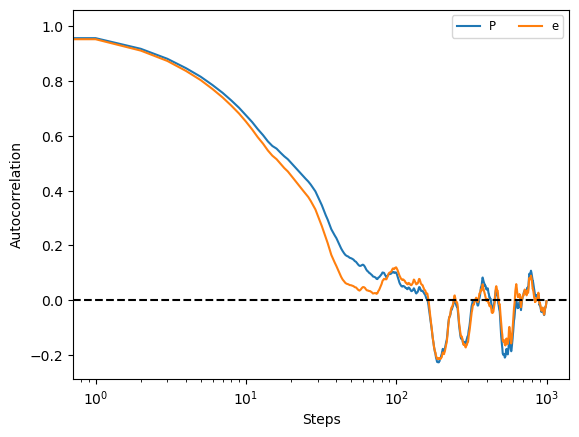

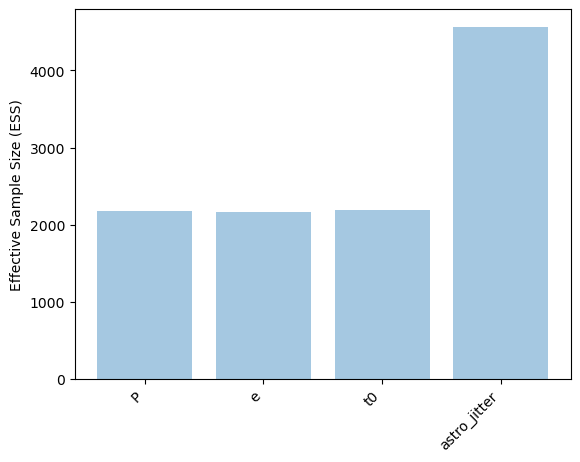

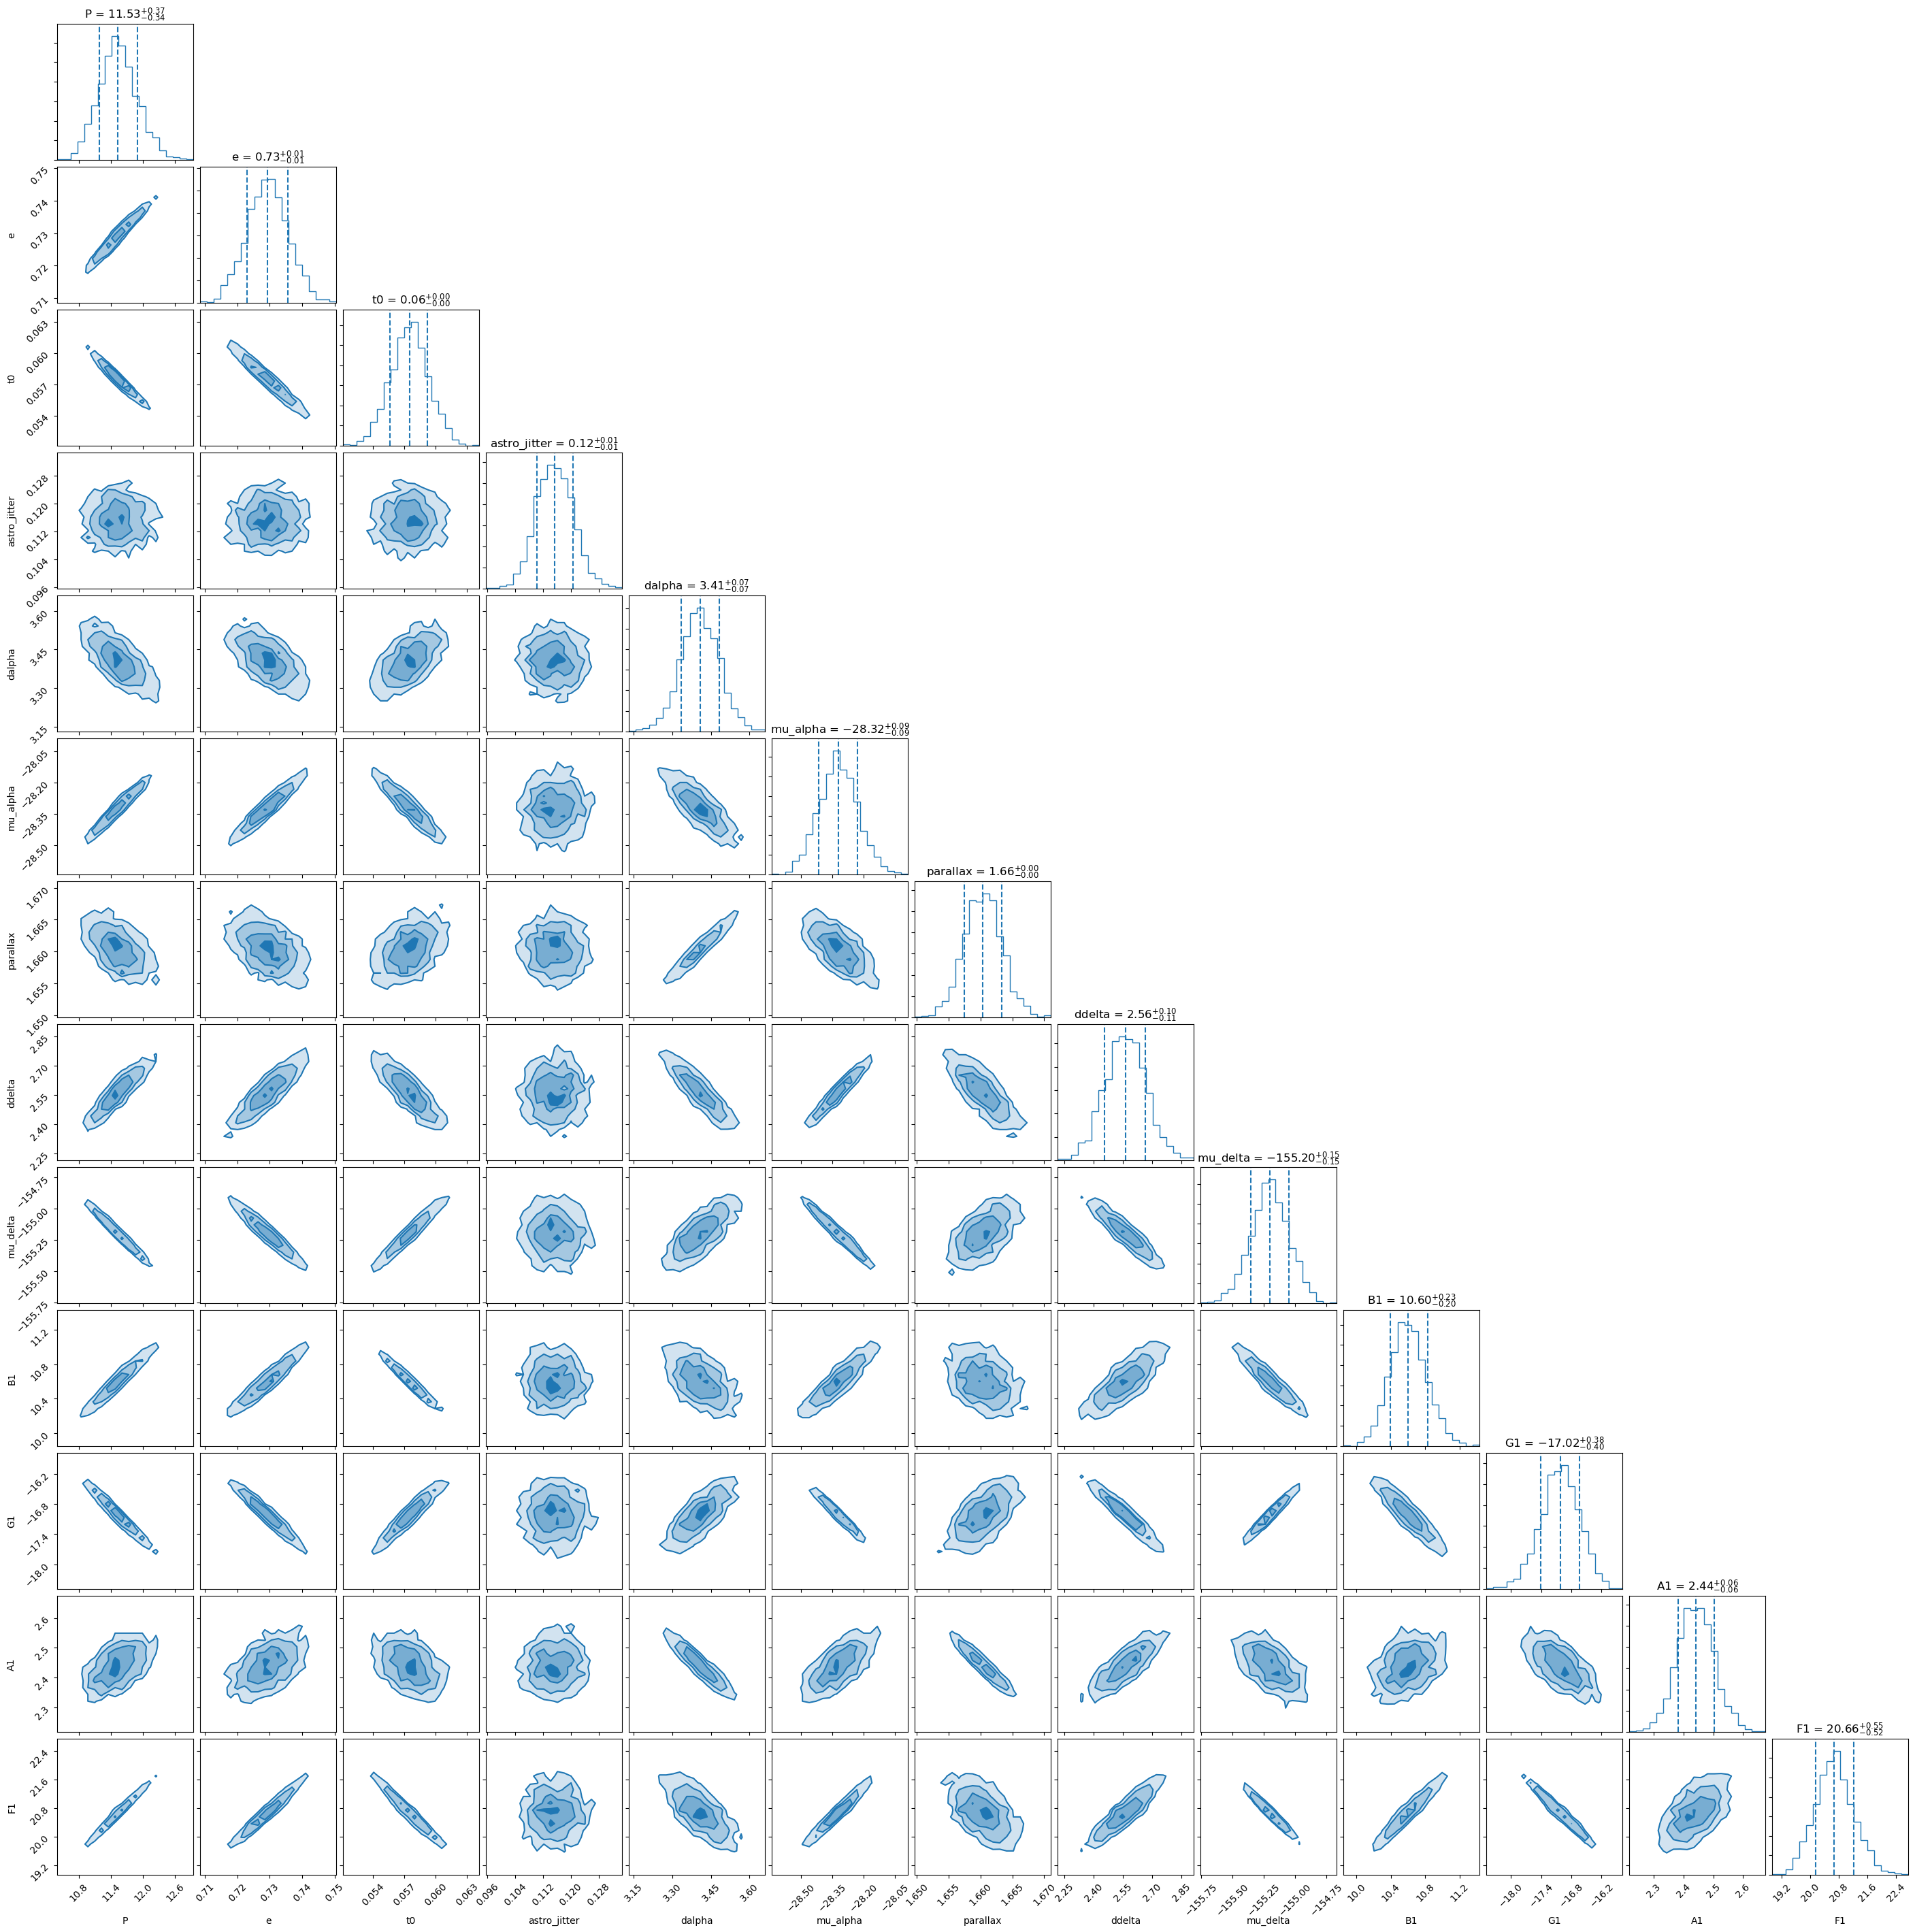

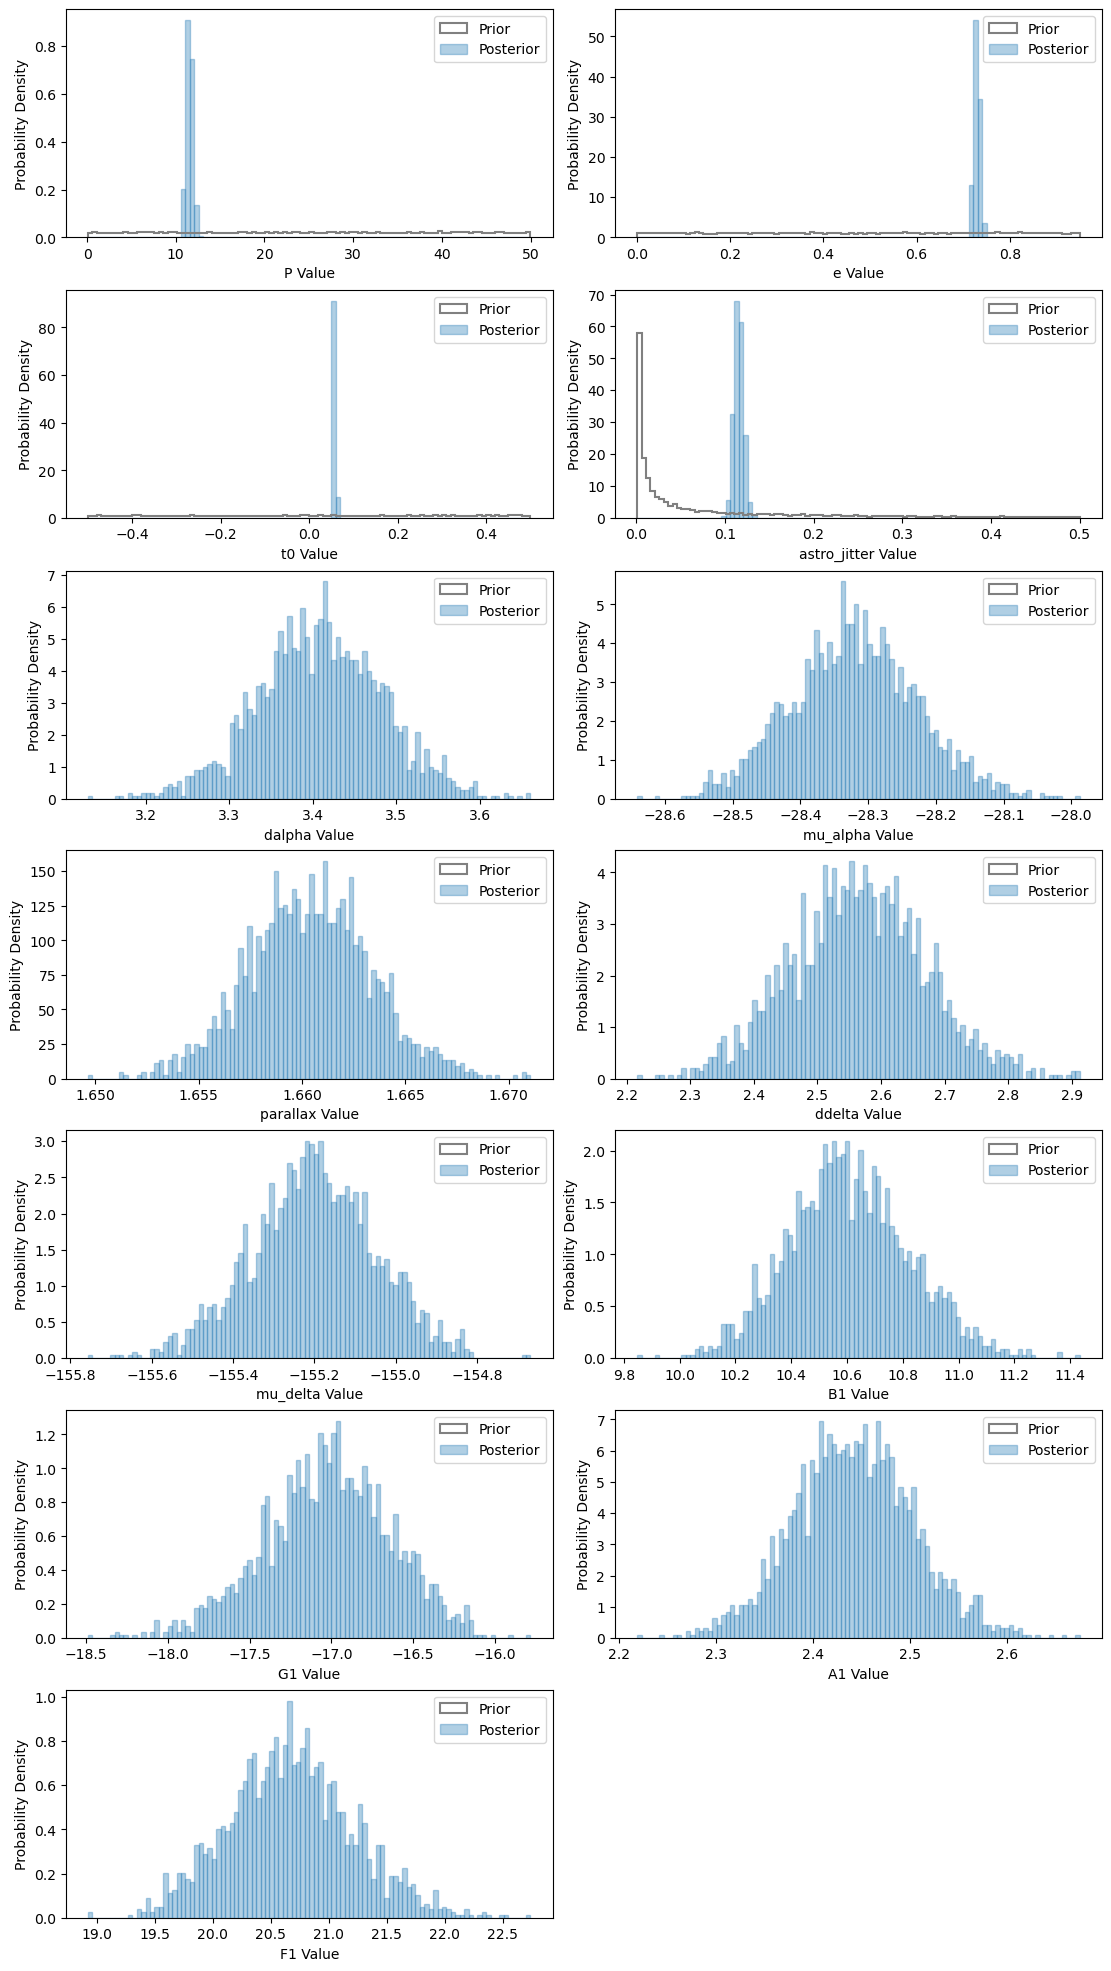

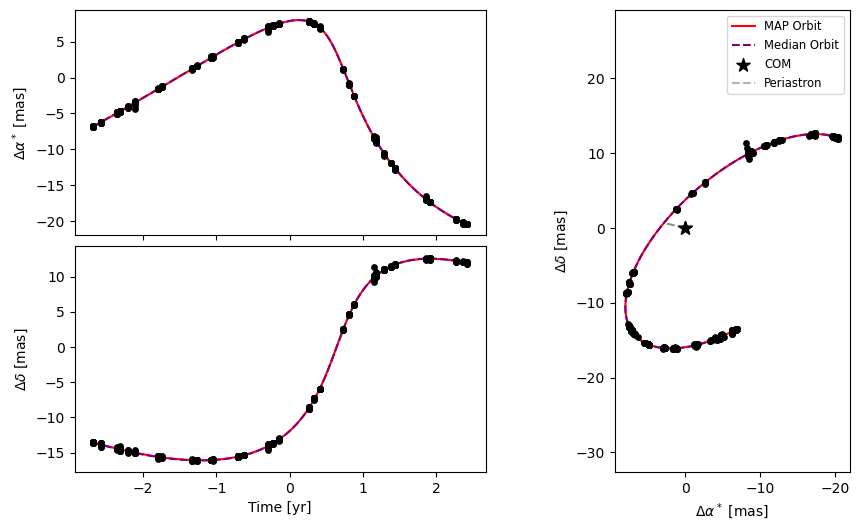

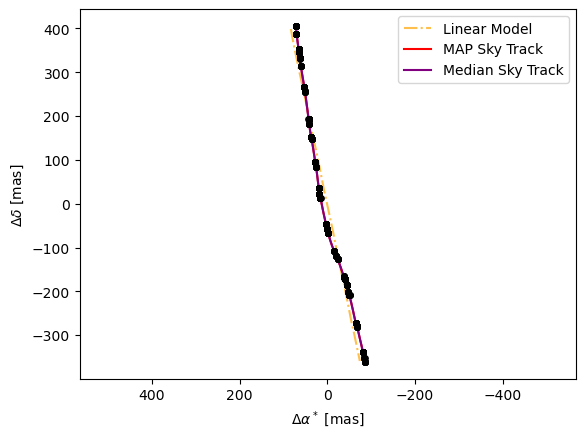

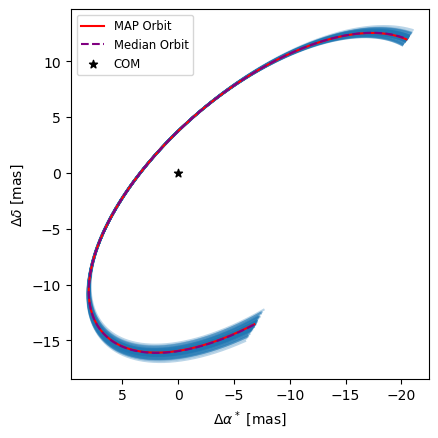

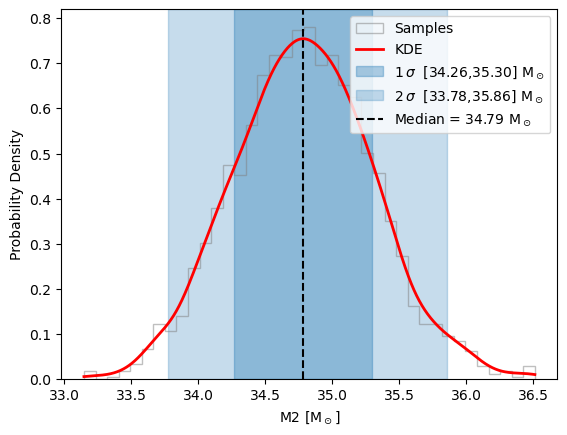

In [10]:
p.all_plots(results1,data)